**This project aims to analyze a dataset that contains Spotify's Top Songs since 2016. Apart from each song's title, number of streams and number of weeks on the charts, it contains information about its audio features, such as valence, danceability and more. It is true that music, depending on these feature can influence a person's mood, while they listen to it. So, I decided to cluster these songs based on 4 different mood playlists.**

**Steps: 1) Import the raw CSV, clean it, conduct EDA, choose features for clustering, create a scaled dataset, k-means clustering, create 4 playlists based on mood.**

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler


**For starters, let's import the csv!**

In [64]:
spotify_df = pd.read_csv('spotify_top_songs_audio_features.csv')
try:
    spotify_df = pd.read_csv('spotify_top_songs_audio_features.csv')
    print("Csv loaded successfully!")
except FileNotFoundError:
    print("File not found! Pls try again!")

Csv loaded successfully!


**Now, let's check what information this dataset contains. I also want to check which columns are numeric and inspect and handle any possible null values.**

In [66]:
spotify_df.head()

,id,artist_names,track_name,source,key,mode,time_signature,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
0,000xQL6tZNLJzIrtIgxqSl,"ZAYN, PARTYNEXTDOOR",Still Got Time (feat. PARTYNEXTDOOR),RCA Records Label,G,Major,4 beats,0.748,0.627,0.0639,0.13100,0.0,0.0852,0.524,-6.029,120.963,188491,17,107527761
1,003eoIwxETJujVWmNFMoZy,Alessia Cara,Growing Pains,Def Jam Recordings,C#/Db,Minor,4 beats,0.353,0.755,0.7330,0.08220,0.0,0.3900,0.437,-6.276,191.153,193680,2,9944865
2,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,Island Records,C#/Db,Major,4 beats,0.352,0.911,0.0747,0.00121,0.0,0.0995,0.236,-5.230,148.033,222973,125,512388123
3,00B7TZ0Xawar6NZ00JFomN,"Cardi B, Chance the Rapper",Best Life (feat. Chance The Rapper),Atlantic/KSR,A,Major,4 beats,0.620,0.625,0.5530,0.28700,0.0,0.3140,0.665,-7.438,167.911,284856,2,11985346
4,00Blm7zeNqgYLPtW6zg8cj,"Post Malone, The Weeknd",One Right Now (with The Weeknd),Republic Records,C#/Db,Major,4 beats,0.687,0.781,0.0530,0.03610,0.0,0.0755,0.688,-4.806,97.014,193507,30,301860377


In [67]:
spotify_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6513 entries, 0 to 6512
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                6513 non-null   object 
 1   artist_names      6513 non-null   object 
 2   track_name        6513 non-null   object 
 3   source            6513 non-null   object 
 4   key               6513 non-null   object 
 5   mode              6513 non-null   object 
 6   time_signature    6513 non-null   object 
 7   danceability      6513 non-null   float64
 8   energy            6513 non-null   float64
 9   speechiness       6513 non-null   float64
 10  acousticness      6513 non-null   float64
 11  instrumentalness  6513 non-null   float64
 12  liveness          6513 non-null   float64
 13  valence           6513 non-null   float64
 14  loudness          6513 non-null   float64
 15  tempo             6513 non-null   float64
 16  duration_ms       6513 non-null   int64  


In [68]:
spotify_df.describe()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
count,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6.513000e+03
mean,0.681731,0.636522,0.121933,0.236761,0.012469,0.180168,0.492412,-6.350667,122.117244,202566.684170,13.614924,1.089647e+08
std,0.141787,0.164813,0.113441,0.244784,0.075151,0.138054,0.227001,2.536114,29.416097,49199.592333,24.084051,2.276695e+08
min,0.150000,0.021800,0.023200,0.000008,0.000000,0.019700,0.032000,-34.475000,46.718000,30133.000000,1.000000,2.525159e+06
25%,0.591000,0.534000,0.044000,0.044400,0.000000,0.097400,0.316000,-7.564000,98.007000,173038.000000,1.000000,8.695060e+06
50%,0.698000,0.651000,0.072200,0.145000,0.000000,0.124000,0.489000,-5.983000,120.034000,198367.000000,4.000000,2.712856e+07
75%,0.785000,0.759000,0.163000,0.356000,0.000041,0.219000,0.669000,-4.673000,142.025000,226003.000000,16.000000,9.951456e+07
max,0.985000,0.989000,0.966000,0.994000,0.953000,0.977000,0.982000,1.509000,212.117000,690732.000000,367.000000,3.528450e+09


In [69]:
spotify_df.isnull().sum()

id                  0
artist_names        0
track_name          0
source              0
key                 0
mode                0
time_signature      0
danceability        0
energy              0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
loudness            0
tempo               0
duration_ms         0
weeks_on_chart      0
streams             0
dtype: int64

**So, what are we looking at? The Spotify Top Songs and Audio Features Dataset contains 6513 rows, each one representing a song. It also features 19 columns, each representing a feature of the song. Since our aim is to distribute these songs into 4 different mood playlists, we need to be able to compare them based on their audio features. For this reason, we will be using the columns that contain numeric data for this clustering analysis, such as valence, danceability, etc. Also, the dataset appears to have no null values, so there is no need for major cleaning.**

In [71]:
features = ['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo']

**The features will be the ones defining the mood. Valence shows how happy a songs is, loudness and energy cover a song's intensity, danceability and tempo show how able it would be for a person to move to the rhythm of that song.**

In [73]:
clustering_dataset = spotify_df[features]

In [74]:
clustering_dataset

,danceability,energy,valence,acousticness,loudness,tempo
0,0.748,0.627,0.524,0.13100,-6.029,120.963
1,0.353,0.755,0.437,0.08220,-6.276,191.153
2,0.352,0.911,0.236,0.00121,-5.230,148.033
3,0.620,0.625,0.665,0.28700,-7.438,167.911
4,0.687,0.781,0.688,0.03610,-4.806,97.014
...,...,...,...,...,...,...
6508,0.615,0.779,0.453,0.06650,-6.454,160.000
6509,0.767,0.313,0.765,0.83800,-12.059,82.582
6510,0.924,0.730,0.848,0.05250,-6.125,99.010
6511,0.727,0.530,0.258,0.28300,-8.616,174.025


In [75]:
scaler = StandardScaler()

In [76]:
clustering_dataset = scaler.fit_transform(clustering_dataset)

In [77]:
clustering_dataset

array([[ 0.46742128, -0.05778086,  0.13916583, -0.43209088,  0.12684413,
        -0.03924152],
       [-2.31865592,  0.71891872, -0.24412251, -0.6314653 ,  0.02944356,
         2.34705024],
       [-2.32570928,  1.66552132, -1.12965074, -0.9623533 ,  0.4419172 ,
         0.88107359],
       ...,
       [ 1.70881264,  0.56721958,  1.56658447, -0.75280589,  0.08898804,
        -0.7855909 ],
       [ 0.31930072, -0.6463735 , -1.03272725,  0.18891141, -0.8932986 ,
         1.76473929],
       [ 0.43920784,  0.4762001 , -0.67146698, -0.55465713,  0.09766339,
         1.11664299]], shape=(6513, 6))

In [78]:
clustering_dataset = pd.DataFrame(clustering_dataset, columns=features, index=spotify_df.index) #let's convert it from an array to a dataframe because it looks better and it's more practical in my opinion

In [79]:
clustering_dataset

,danceability,energy,valence,acousticness,loudness,tempo
0,0.467421,-0.057781,0.139166,-0.432091,0.126844,-0.039242
1,-2.318656,0.718919,-0.244123,-0.631465,0.029444,2.347050
2,-2.325709,1.665521,-1.129651,-0.962353,0.441917,0.881074
3,-0.435409,-0.069917,0.760357,0.205254,-0.428773,1.556878
4,0.037166,0.876686,0.861686,-0.819809,0.609115,-0.853450
...,...,...,...,...,...,...
6508,-0.470676,0.864550,-0.173633,-0.695608,-0.040748,1.287923
6509,0.601435,-1.963122,1.200919,2.456387,-2.250991,-1.344104
6510,1.708813,0.567220,1.566584,-0.752806,0.088988,-0.785591
6511,0.319301,-0.646374,-1.032727,0.188911,-0.893299,1.764739


**Now that all of our data is in the same form, we can actually implement ML models efficiently!**

In [82]:
from sklearn.cluster import KMeans

In [98]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(clustering_dataset)
y_kmeans=kmeans.predict(clustering_dataset)

**We trained our model and now assigned each song to a cluster. Let's visualise it and make sure this is right!**

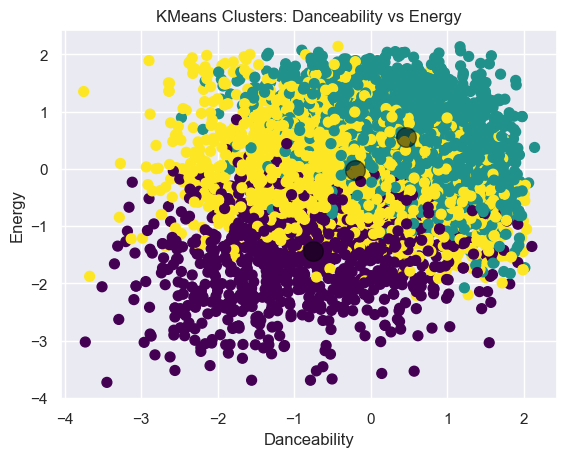

In [100]:
plt.scatter(clustering_dataset['danceability'], clustering_dataset['energy'], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.title('KMeans Clusters: Danceability vs Energy')
plt.show()

In [101]:
spotify_df['cluster'] = y_kmeans

In [102]:
spotify_df.groupby('cluster')[['danceability','energy','valence','acousticness','loudness','tempo']].mean()

,danceability,energy,valence,acousticness,loudness,tempo
cluster,,,,,,
0,0.574978,0.398669,0.364407,0.640781,-9.754065,115.339581
1,0.747384,0.728433,0.683719,0.179088,-5.077622,122.528906
2,0.652990,0.631765,0.335201,0.137508,-6.372860,124.388296


In [103]:
#Cluster 0 : High acousticness, very low loudness, medium danceability and low avlence and energy. Indicates a more chill, acoustic vibe of playlist.
#Cluster 1: High danceability, energy, valence, very low acousticness and moderate loudness. This is the party, upbeat playlist.
#Cluster 2: Fair danceability and valence, very low valence and acousticness. This is a more dark, intense playlist.

In [106]:
spotify_df['playlist_name'] = spotify_df['cluster'].map({0: 'Chill Vibe', 1: 'Party Feel-Good Vibe', 2: 'Dark, Intense Vibe'})

In [111]:
new_spotify_df=spotify_df[['id','track_name', 'artist_names', 'cluster', 'playlist_name']]

In [112]:
new_spotify_df.head()

,id,track_name,artist_names,cluster,playlist_name
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),"ZAYN, PARTYNEXTDOOR",1,Party Feel-Good Vibe
1,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,2,"Dark, Intense Vibe"
2,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,2,"Dark, Intense Vibe"
3,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),"Cardi B, Chance the Rapper",1,Party Feel-Good Vibe
4,00Blm7zeNqgYLPtW6zg8cj,One Right Now (with The Weeknd),"Post Malone, The Weeknd",1,Party Feel-Good Vibe


In [113]:
chill_playlist = new_spotify_df[new_spotify_df['playlist_name']=='Chill Vibe']
party_playlist = new_spotify_df[new_spotify_df['playlist_name']=='Party Feel-Good Vibe']
dark_playlist = new_spotify_df[new_spotify_df['playlist_name']=='Dark, Intense Vibe']

In [116]:
chill_playlist.to_csv('chill_playlist.csv', index=False)
party_playlist.to_csv('party_playlist.csv', index=False)
dark_playlist.to_csv('dark_playlist.csv', index=False)

In [119]:
!pip install spotipy 
#https://spotipy.readthedocs.io/en/2.26.0/ more info on the spotipy library here

In [120]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth

In [123]:
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id="CLIENTID",
    client_secret="a3a5317b270c42fbbaf3c71908cdb5d4",
    redirect_uri="http://127.0.0.1:8888/callback",
    scope="user-read-private playlist-modify-private playlist-modify-public"
))

In [124]:
user_id = sp.current_user()["id"]

PermissionError: [WinError 10013] An attempt was made to access a socket in a way forbidden by its access permissions